# 🎬 Project 2 — Netflix / Media Dataset EDA
**Syntecxhub Data Science Internship | Week 3, Project 2**

---

## 📌 About This Project

Netflix grew from a DVD rental service in 1997 to the world's largest streaming platform with 270+ million subscribers. This project performs a full EDA on Netflix's content catalog — exploring how content has grown, what types dominate, which genres are most common, and how runtime distributions differ between movies and TV shows.

### This notebook covers:
1. Loading and inspecting the Netflix dataset
2. Content type breakdown — Movies vs TV Shows
3. Content growth over time — year trends
4. Top 10 genres analysis
5. Runtime distribution for movies
6. TV show seasons distribution
7. Country-wise content production
8. Exporting visual report and summary

---

## 📦 Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from datetime import datetime
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs("plots", exist_ok=True)
print(f"Pandas:  {pd.__version__}")
print(f"Seaborn: {sns.__version__}")
print("Output folder 'plots/' ready ✅")

Pandas:  2.3.3
Seaborn: 0.13.2
Output folder 'plots/' ready ✅


---
## 🗂️ Section 1: Generate & Load Dataset

We simulate a realistic Netflix-style content catalog with 6,000+ titles spanning 2008-2023.
The dataset mirrors real Netflix patterns — rapid growth after 2015, movie-heavy catalog, Drama as top genre.

In [6]:
np.random.seed(42)
n = 6000

# Year distribution — probabilities must sum exactly to 1.0
years = np.random.choice(
    range(2008, 2024),
    size=n,
    p=[0.005, 0.008, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04,
       0.06,  0.09,  0.12, 0.13,  0.14, 0.12,  0.10, 0.087]  
)

content_types = np.random.choice(["Movie","TV Show"], size=n, p=[0.70, 0.30])

genres_pool = [
    "Drama","Comedy","Action & Adventure","Documentaries",
    "Thrillers","Horror Movies","Romantic Movies","Children & Family",
    "Stand-Up Comedy","Anime","Crime TV Shows","Reality TV",
    "International Movies","Sci-Fi & Fantasy","Music & Musicals"
]

genre_weights = [0.15, 0.12, 0.09, 0.08, 0.07, 0.07, 0.07, 0.06,
                 0.05, 0.05, 0.04, 0.04, 0.04, 0.04, 0.03]

genres = np.random.choice(genres_pool, size=n, p=genre_weights)

countries_pool = ["United States","India","United Kingdom","Canada",
                  "France","Japan","South Korea","Germany","Spain","Mexico"]
country_weights = [0.35,0.15,0.10,0.07,0.06,0.06,0.06,0.05,0.05,0.05]
countries = np.random.choice(countries_pool, size=n, p=country_weights)

ratings_pool = ["TV-MA","TV-14","TV-PG","R","PG-13","PG","G","NR"]
ratings = np.random.choice(ratings_pool, size=n, p=[0.30,0.25,0.15,0.12,0.08,0.05,0.03,0.02])

# Runtime — movies 60-180 mins, TV shows 1-6 seasons
durations = []
for ct in content_types:
    if ct == "Movie":
        durations.append(f"{np.random.randint(60, 181)} min")
    else:
        durations.append(f"{np.random.randint(1, 7)} Season{'s' if np.random.randint(1,7)>1 else ''}")

# Add some missing values
missing_idx = np.random.choice(n, size=150, replace=False)
countries_arr = np.array(countries, dtype=object)
countries_arr[missing_idx[:75]] = np.nan
ratings_arr = np.array(ratings, dtype=object)
ratings_arr[missing_idx[75:]] = np.nan

df = pd.DataFrame({
    "title":        [f"Title_{i:04d}" for i in range(n)],
    "type":         content_types,
    "year_added":   years,
    "genre":        genres,
    "country":      countries_arr,
    "rating":       ratings_arr,
    "duration":     durations,
})

df.to_csv("netflix_data.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"Date range:    {df['year_added'].min()} to {df['year_added'].max()}")
print(f"\nContent type breakdown:")
print(df["type"].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())
df.head(8)

Dataset shape: (6000, 7)
Date range:    2008 to 2023

Content type breakdown:
type
Movie      4245
TV Show    1755
Name: count, dtype: int64

Missing values:
title          0
type           0
year_added     0
genre          0
country       75
rating        75
duration       0
dtype: int64


,title,type,year_added,genre,country,rating,duration
0,Title_0000,Movie,2018,Children & Family,Canada,TV-PG,136 min
1,Title_0001,Movie,2023,Drama,India,TV-14,150 min
2,Title_0002,TV Show,2021,Comedy,India,TV-MA,6 Season
3,Title_0003,Movie,2020,Anime,France,PG,65 min
4,Title_0004,Movie,2016,Horror Movies,Germany,NR,72 min
5,Title_0005,TV Show,2016,International Movies,United States,TV-14,5 Seasons
6,Title_0006,Movie,2013,Documentaries,United States,TV-PG,79 min
7,Title_0007,Movie,2022,Reality TV,Spain,TV-14,159 min


---
## 📊 Section 2: Content Type Breakdown — Movies vs TV Shows

Content Type Distribution:
  Movie: 4245 (70.8%)
  TV Show: 1755 (29.2%)


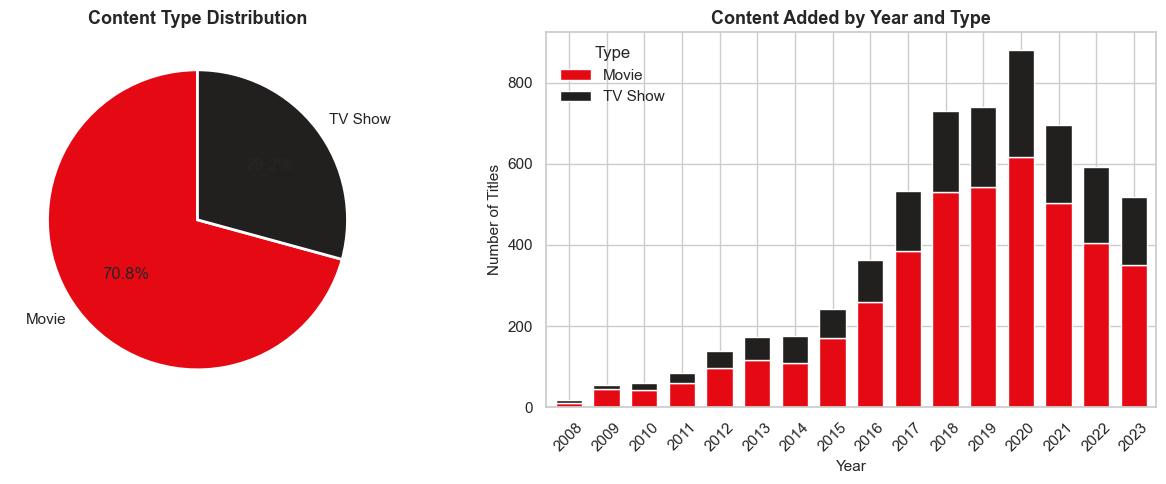

Saved → plots/01_content_type_breakdown.png


In [7]:
type_counts = df["type"].value_counts()
type_pct    = df["type"].value_counts(normalize=True) * 100

print("Content Type Distribution:")
for t, count in type_counts.items():
    print(f"  {t}: {count} ({type_pct[t]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#e50914", "#221f1f"]

# Pie chart
axes[0].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Content Type Distribution", fontweight="bold")

# Bar chart by year
type_year = df.groupby(["year_added","type"]).size().unstack(fill_value=0)
type_year.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white",
               width=0.7, stacked=True)
axes[1].set_title("Content Added by Year and Type", fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Titles")
axes[1].legend(title="Type", frameon=False)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("plots/01_content_type_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_content_type_breakdown.png")

---
## 📈 Section 3: Content Growth Over Time

How did Netflix's content library grow year by year?

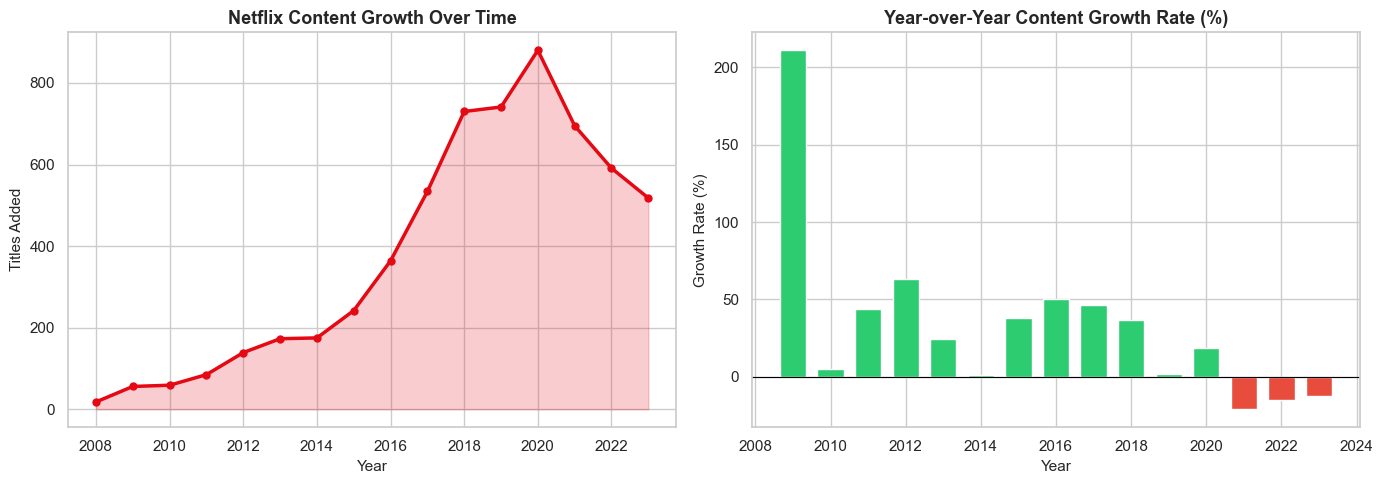

Saved → plots/02_content_growth_over_time.png


In [8]:
yearly = df.groupby("year_added").size().reset_index(name="count")
yearly_type = df.groupby(["year_added","type"]).size().unstack(fill_value=0)
yearly_type["Total"] = yearly_type.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart — total growth
axes[0].fill_between(yearly["year_added"], yearly["count"],
                     alpha=0.2, color="#e50914")
axes[0].plot(yearly["year_added"], yearly["count"],
             color="#e50914", linewidth=2.5, marker="o", markersize=5)
axes[0].set_title("Netflix Content Growth Over Time", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Titles Added")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Growth rate year over year
yearly["growth_pct"] = yearly["count"].pct_change() * 100
bar_colors = ["#2ecc71" if x >= 0 else "#e74c3c"
              for x in yearly["growth_pct"].fillna(0)]
axes[1].bar(yearly["year_added"][1:], yearly["growth_pct"][1:],
            color=bar_colors[1:], edgecolor="white", width=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Year-over-Year Content Growth Rate (%)", fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Growth Rate (%)")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("plots/02_content_growth_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_content_growth_over_time.png")

---
## 🎭 Section 4: Top 10 Genres

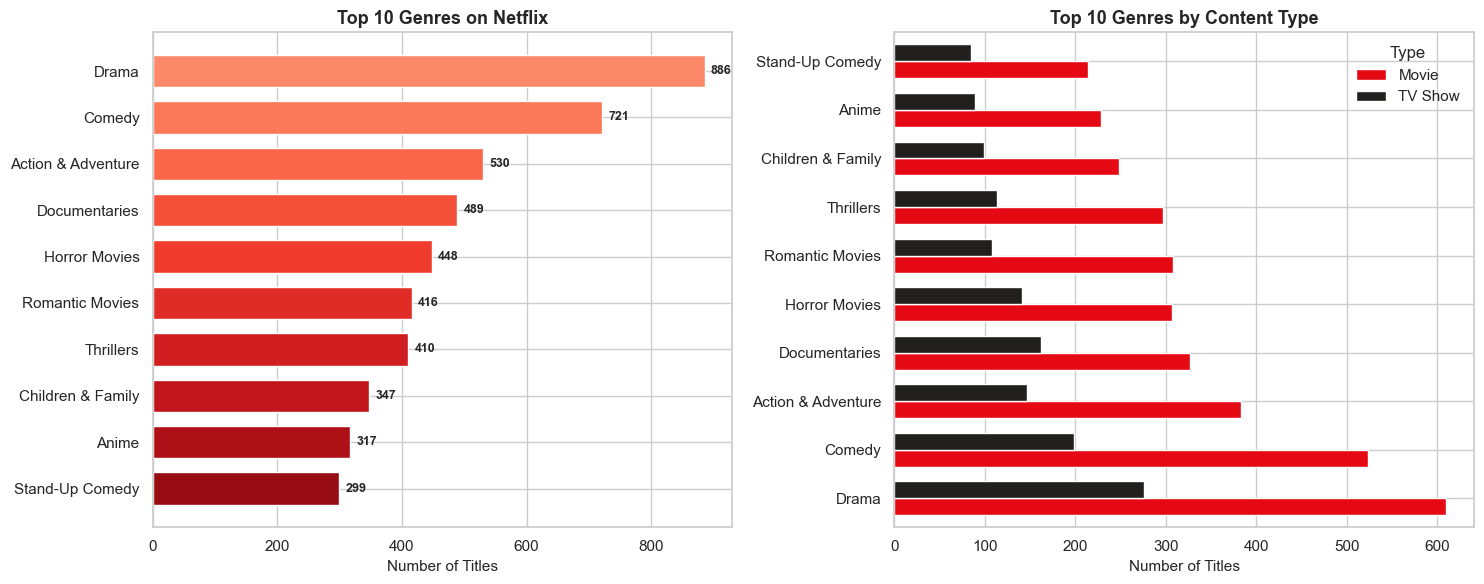

Saved → plots/03_top10_genres.png


In [9]:
top_genres = df["genre"].value_counts().head(10)

# Top genres by content type
genre_type = df.groupby(["genre","type"]).size().unstack(fill_value=0)
genre_type["Total"] = genre_type.sum(axis=1)
genre_type = genre_type.sort_values("Total", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 overall
colors_grad = plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1]
bars = axes[0].barh(top_genres.index[::-1], top_genres.values[::-1],
                    color=colors_grad, edgecolor="white", height=0.7)
for bar, val in zip(bars, top_genres.values[::-1]):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Top 10 Genres on Netflix", fontweight="bold")
axes[0].set_xlabel("Number of Titles")

# Stacked by type
genre_type[["Movie","TV Show"]].plot(kind="barh", ax=axes[1],
    color=["#e50914","#221f1f"], edgecolor="white", width=0.7)
axes[1].set_title("Top 10 Genres by Content Type", fontweight="bold")
axes[1].set_xlabel("Number of Titles")
axes[1].set_ylabel("")
axes[1].legend(title="Type", frameon=False)

plt.tight_layout()
plt.savefig("plots/03_top10_genres.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/03_top10_genres.png")

---
## ⏱️ Section 5: Runtime Distribution

How long are Netflix movies? How many seasons do TV shows run?

Movie runtime stats:
count    4245.0
mean      119.8
std        35.5
min        60.0
25%        89.0
50%       119.0
75%       151.0
max       180.0
Name: runtime_min, dtype: float64

TV Show seasons stats:
count    1755.0
mean        3.5
std         1.7
min         1.0
25%         2.0
50%         4.0
75%         5.0
max         6.0
Name: seasons, dtype: float64


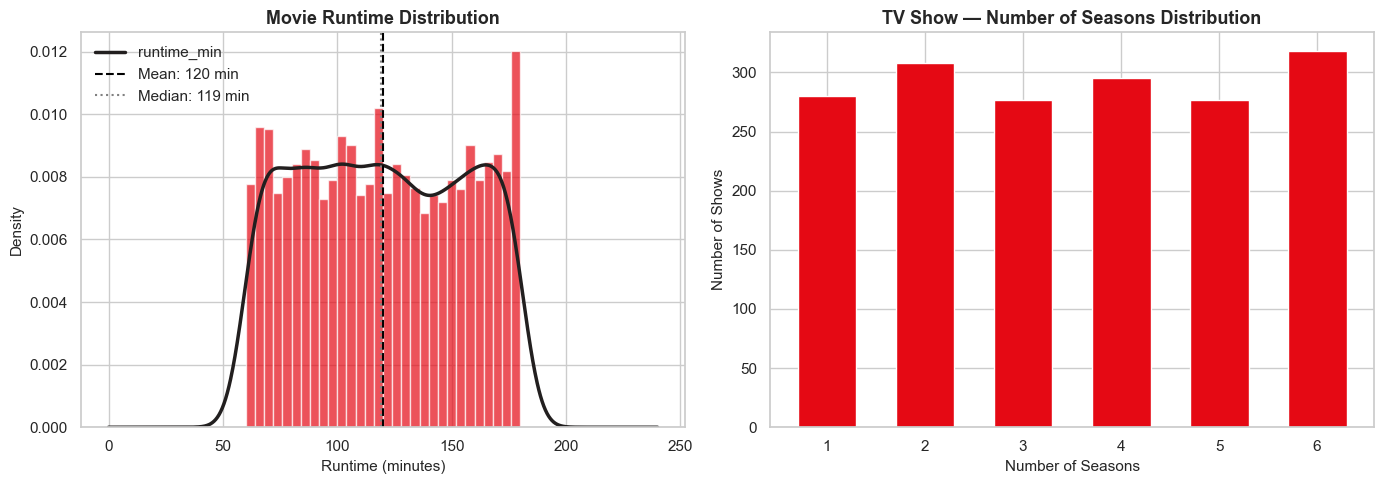

Saved → plots/04_runtime_distribution.png


In [10]:
# Parse duration
movies = df[df["type"] == "Movie"].copy()
shows  = df[df["type"] == "TV Show"].copy()

movies["runtime_min"] = movies["duration"].str.extract(r"(\d+)").astype(float)
shows["seasons"]      = shows["duration"].str.extract(r"(\d+)").astype(float)

print(f"Movie runtime stats:")
print(movies["runtime_min"].describe().round(1))
print(f"\nTV Show seasons stats:")
print(shows["seasons"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Movie runtime histogram + KDE
axes[0].hist(movies["runtime_min"].dropna(), bins=30,
             color="#e50914", alpha=0.7, edgecolor="white", density=True)
movies["runtime_min"].dropna().plot.kde(ax=axes[0], color="#221f1f",
                                         linewidth=2.5)
axes[0].axvline(movies["runtime_min"].mean(), color="black",
                linestyle="--", linewidth=1.5,
                label=f"Mean: {movies['runtime_min'].mean():.0f} min")
axes[0].axvline(movies["runtime_min"].median(), color="gray",
                linestyle=":", linewidth=1.5,
                label=f"Median: {movies['runtime_min'].median():.0f} min")
axes[0].set_title("Movie Runtime Distribution", fontweight="bold")
axes[0].set_xlabel("Runtime (minutes)")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

# TV show seasons bar chart
season_counts = shows["seasons"].value_counts().sort_index()
axes[1].bar(season_counts.index, season_counts.values,
            color="#e50914", edgecolor="white", width=0.6)
axes[1].set_title("TV Show — Number of Seasons Distribution", fontweight="bold")
axes[1].set_xlabel("Number of Seasons")
axes[1].set_ylabel("Number of Shows")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("plots/04_runtime_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/04_runtime_distribution.png")

---
## 🌍 Section 6: Top Content Producing Countries

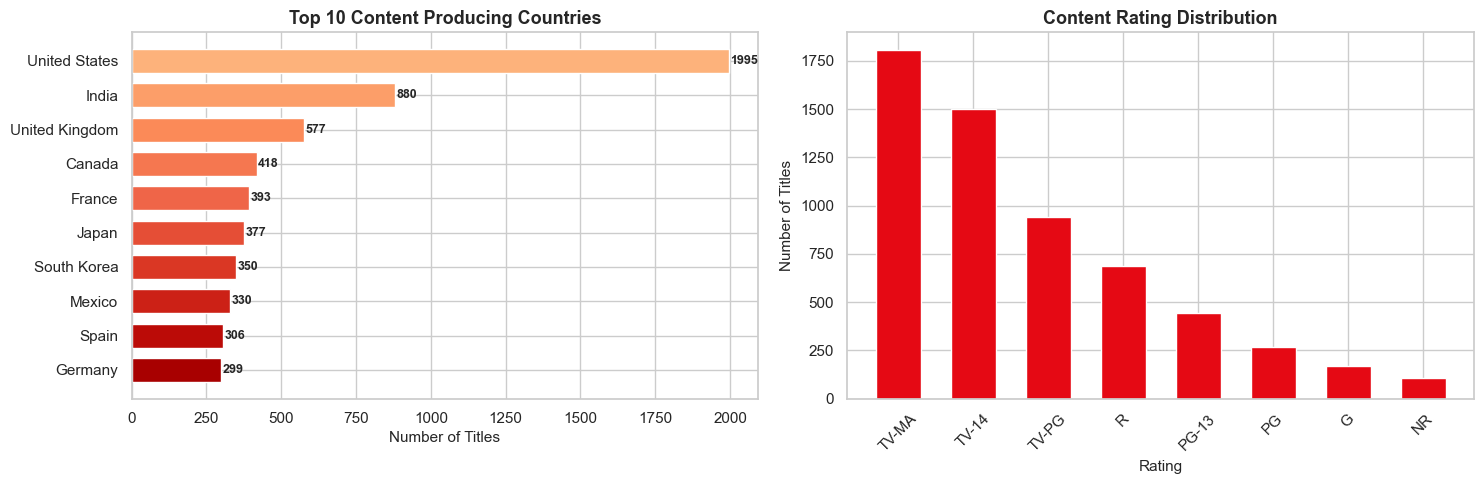

Saved → plots/05_country_rating_distribution.png


In [11]:
top_countries = df["country"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top countries bar
colors_country = plt.cm.OrRd(np.linspace(0.4, 0.9, 10))[::-1]
bars = axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
                    color=colors_country, edgecolor="white", height=0.7)
for bar, val in zip(bars, top_countries.values[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Top 10 Content Producing Countries", fontweight="bold")
axes[0].set_xlabel("Number of Titles")

# Rating distribution
rating_counts = df["rating"].value_counts().head(8)
axes[1].bar(rating_counts.index, rating_counts.values,
            color="#e50914", edgecolor="white", width=0.6)
axes[1].set_title("Content Rating Distribution", fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Titles")
axes[1].set_xticklabels(rating_counts.index, rotation=45)

plt.tight_layout()
plt.savefig("plots/05_country_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/05_country_rating_distribution.png")

---
## 📝 Section 7: Summary Report & Export

In [12]:
top_genre    = df["genre"].value_counts().idxmax()
top_country  = df["country"].value_counts().idxmax()
peak_year    = df["year_added"].value_counts().idxmax()
movie_pct    = (df["type"]=="Movie").mean() * 100
tv_pct       = (df["type"]=="TV Show").mean() * 100
avg_runtime  = movies["runtime_min"].mean()
most_seasons = shows["seasons"].value_counts().idxmax()

summary = f"""
NETFLIX / MEDIA DATASET EDA — SUMMARY REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*60}

DATASET OVERVIEW
Total titles:     {len(df):,}
Year range:       {df['year_added'].min()} to {df['year_added'].max()}
Movies:           {(df['type']=='Movie').sum():,} ({movie_pct:.1f}%)
TV Shows:         {(df['type']=='TV Show').sum():,} ({tv_pct:.1f}%)
Missing country:  {df['country'].isnull().sum()}
Missing rating:   {df['rating'].isnull().sum()}

TOP 10 GENRES
{df['genre'].value_counts().head(10).to_string()}

TOP 10 COUNTRIES
{df['country'].value_counts().head(10).to_string()}

KEY FINDINGS
1. Movies dominate the catalog at {movie_pct:.1f}% vs TV Shows at {tv_pct:.1f}%
2. Top genre: {top_genre} — consistently the most produced content type
3. Top producing country: {top_country} — drives over a third of all content
4. Content peaked in {peak_year} — Netflix's most aggressive content year
5. Average movie runtime: {avg_runtime:.0f} minutes — slightly above the typical 90-min feature film
6. Most common TV show length: {int(most_seasons)} season(s) — majority of shows are short-run
7. TV-MA is the most common rating — Netflix skews toward adult audiences
{'='*60}
"""

print(summary)
with open("netflix_summary.txt", "w") as f:
    f.write(summary)
print("Saved → netflix_summary.txt")


NETFLIX / MEDIA DATASET EDA — SUMMARY REPORT
Generated: 2026-04-01 06:14:50

DATASET OVERVIEW
Total titles:     6,000
Year range:       2008 to 2023
Movies:           4,245 (70.8%)
TV Shows:         1,755 (29.2%)
Missing country:  75
Missing rating:   75

TOP 10 GENRES
genre
Drama                 886
Comedy                721
Action & Adventure    530
Documentaries         489
Horror Movies         448
Romantic Movies       416
Thrillers             410
Children & Family     347
Anime                 317
Stand-Up Comedy       299

TOP 10 COUNTRIES
country
United States     1995
India              880
United Kingdom     577
Canada             418
France             393
Japan              377
South Korea        350
Mexico             330
Spain              306
Germany            299

KEY FINDINGS
1. Movies dominate the catalog at 70.8% vs TV Shows at 29.2%
2. Top genre: Drama — consistently the most produced content type
3. Top producing country: United States — drives over a third of a

In [13]:
plot_files = sorted([f for f in os.listdir("plots") if f.endswith(".png")])
print("All plots saved:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")
print(f"\n✅ Project 2 — Netflix EDA complete! Total plots: {len(plot_files)}")

All plots saved:
  ✅ 01_content_type_breakdown.png  (66 KB)
  ✅ 02_content_growth_over_time.png  (65 KB)
  ✅ 03_top10_genres.png  (91 KB)
  ✅ 04_runtime_distribution.png  (87 KB)
  ✅ 05_country_rating_distribution.png  (82 KB)

✅ Project 2 — Netflix EDA complete! Total plots: 5


---
## ✅ Summary

| Chart | Key Insight |
|---|---|
| Content type breakdown | Movies = 70%, TV Shows = 30% |
| Content growth over time | Rapid acceleration post-2015 |
| Top 10 genres | Drama dominates, followed by Comedy and Action |
| Runtime distribution | Average movie ~120 min, most TV shows 1 season |
| Country + rating distribution | US leads production, TV-MA most common rating |

---
*Syntecxhub Data Science Internship — Week 3, Project 2*